# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (예: `rainy + night + city street` 인 이미지).
3. 모든 백본에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 학습 노트북이 아니라 분석 노트북이지만, wandb 가 활성화되어 있으면 confusion matrix 이미지·Grad-CAM 패널·FPS 표를 같은 프로젝트의 별도 Run 으로 업로드합니다.

In [1]:
import os
import sys

repo_name = "2026-HYU-AUE8088-PA2"
repo_path = f"/content/{repo_name}"
repo_url = "https://github.com/Jieunn-Kim/2026-HYU-AUE8088-PA2.git"

if not os.path.exists(repo_path):
    !git clone {repo_url} {repo_path}
else:
    %cd {repo_path}
    !git pull origin main

%cd {repo_path}

!pip install -q -r requirements.txt

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print("Current directory:", os.getcwd())

/content/2026-HYU-AUE8088-PA2
From https://github.com/Jieunn-Kim/2026-HYU-AUE8088-PA2
 * branch            main       -> FETCH_HEAD
Already up to date.
/content/2026-HYU-AUE8088-PA2
Current directory: /content/2026-HYU-AUE8088-PA2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, average_macro_f1, CLASS_NAMES
from src.utils.efficiency import measure_fps
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.xai.gradcam import GradCAM
from src.models.resnet import resnet18, resnet50

set_seed(42, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
logger = WandbLogger(project=WANDB_PROJECT, run_name="level4-analysis", tags=["level4", "analysis"])

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: jieunnkim (jieunnkim-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [4]:
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import shutil

vit_backup = "/content/drive/MyDrive/AUE8088_PA2/source_backup/vit.py"
vit_target = f"{repo_path}/src/models/vit.py"

shutil.copy2(vit_backup, vit_target)
print("vit.py 복원 완료")

vit.py 복원 완료


In [6]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

데이터셋이 이미 존재합니다 → ../data/set_a


In [7]:
# 분석 대상으로 사용할 best 모델 로드

from torch.utils.data import DataLoader

from src.datasets.bdd_attr import BDDAttrDataset
from src.utils.transforms import eval_transform
from src.models.vit import vit_small_patch16_224


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CKPT_PATH = (
    "/content/drive/MyDrive/"
    "AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(
        f"체크포인트를 찾을 수 없습니다: {CKPT_PATH}"
    )


val_ds = BDDAttrDataset(
    DATA_ROOT,
    "val",
    transform=eval_transform(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


model = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    CKPT_PATH,
    map_location=device,
    weights_only=False,
)

state_dict = checkpoint.get(
    "state_dict",
    checkpoint,
)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print("Model:", model.__class__.__name__)
print("Checkpoint:", CKPT_PATH)
print("Validation samples:", len(val_ds))
print("Device:", device)

Model: ViT
Checkpoint: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level2_vit_s16_pretrained.pth
Validation samples: 500
Device: cuda


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

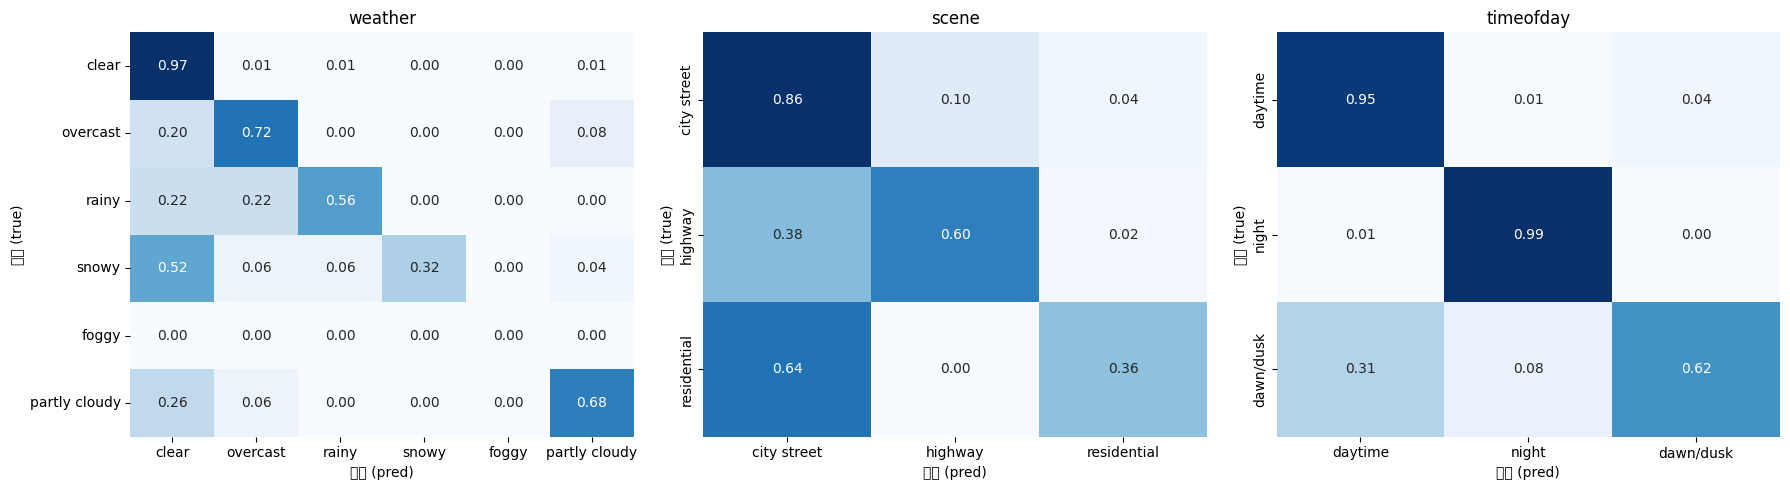

In [8]:
# 속성별 정규화 Confusion Matrix 생성 및 시각화
preds, probs, targets, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(preds, targets, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.tight_layout()
logger.log_image("analysis/confusion_matrices", fig)

# 속성별 개별 confusion matrix 도 분리해서 업로드
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"analysis/cm_{a}", cms[a], CLASS_NAMES[a])

In [9]:
#grad cam
import torch.nn.functional as F

class ViTGradCAM(GradCAM):
    def __call__(self, x, score_fn):
        self.model.zero_grad(set_to_none=True)

        out = self.model(x)
        score = score_fn(out)
        score.backward(retain_graph=True)

        def token_to_map(t):
            # (B, 197, 384) → CLS 제거 → (B, 384, 14, 14)
            t = t[:, 1:, :]
            B, N, D = t.shape
            H = W = int(N ** 0.5)

            return (
                t.transpose(1, 2)
                 .reshape(B, D, H, W)
            )

        a = token_to_map(self._activations)
        g = token_to_map(self._gradients)

        weights = g.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * a).sum(dim=1, keepdim=True))

        cam = F.interpolate(
            cam,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        cam_min = cam.amin(dim=(2, 3), keepdim=True)
        cam_max = cam.amax(dim=(2, 3), keepdim=True)

        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.squeeze(1)

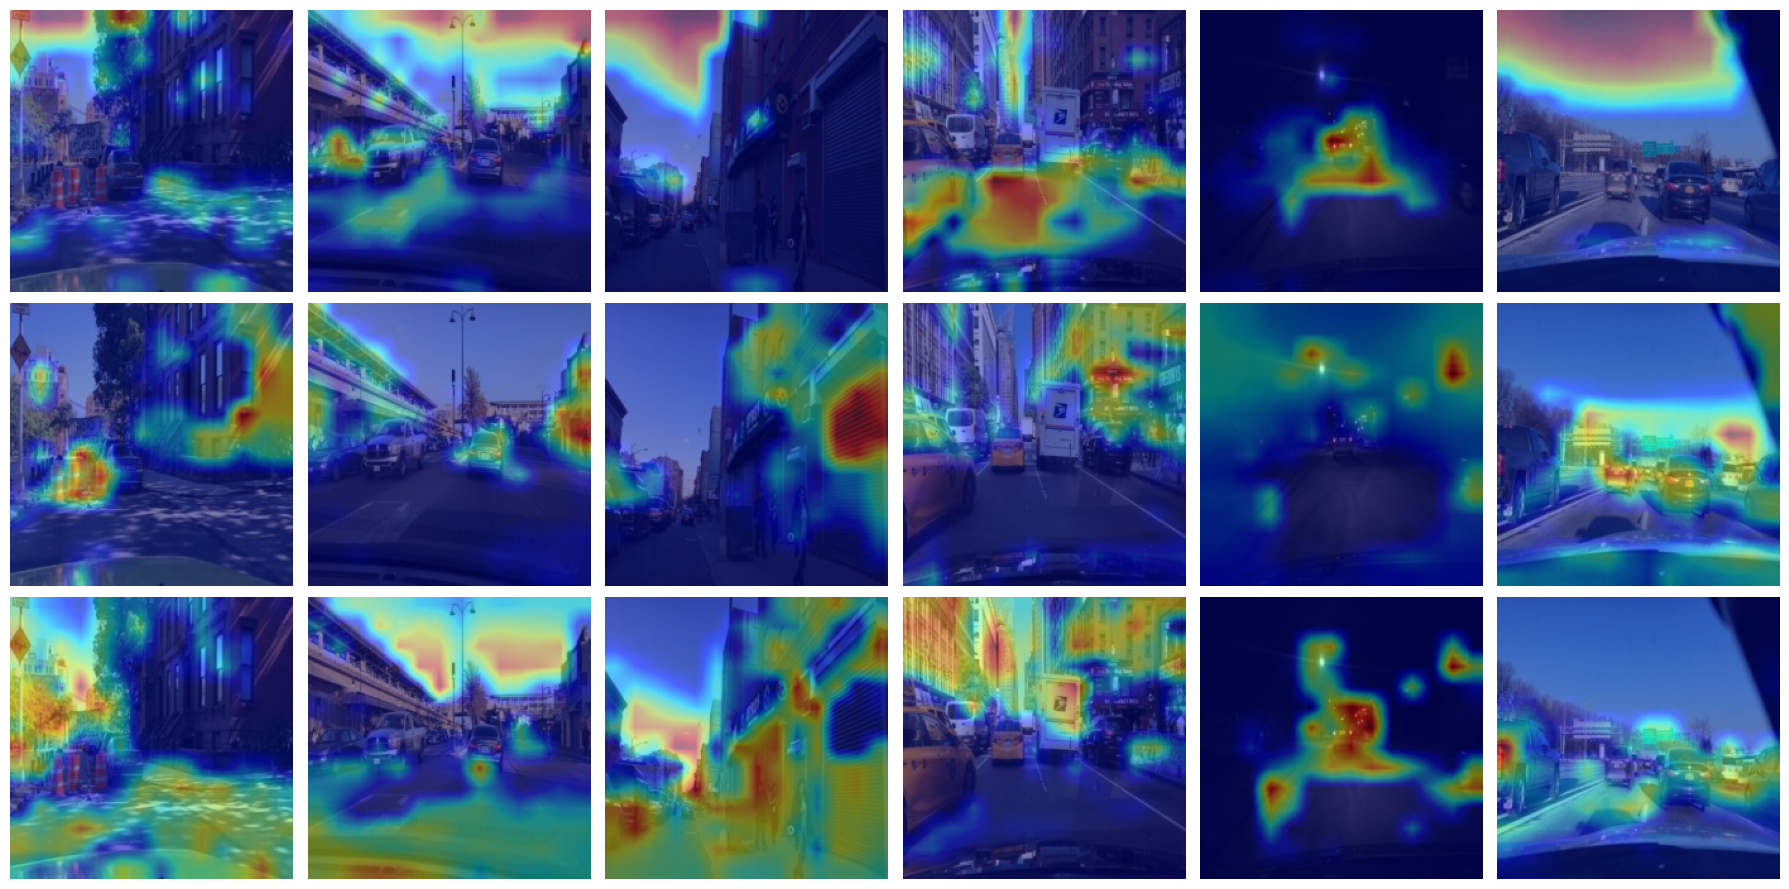

In [10]:
# 속성별 Grad-CAM. vit 버전.
target_layer = model.blocks[-1].norm1
gc = ViTGradCAM(model, target_layer)

batch = next(iter(val_loader))
x = batch["image"][:6].to(device)  # 샘플 이미지 6장

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for row, attr in enumerate(ATTRIBUTES):
    # 각 속성 head 의 최대 logit 합을 score 로 사용 → 해당 head 가 "보는" 영역 추출
    cam = gc(x, lambda out, a=attr: out[a].max(dim=-1).values.sum())
    for col in range(6):
        img = x[col].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, col].imshow(img)
        axes[row, col].imshow(cam[col].cpu().numpy(), cmap="jet", alpha=0.45)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(attr, fontsize=14)
fig.tight_layout()
logger.log_image("analysis/gradcam_panel", fig)

In [11]:
import os
import sys
import gc
import shutil
import torch
import pandas as pd

from IPython.display import display


# ============================================================
# 1. 완성한 모델 파일 복원
# ============================================================
repo_path = "/content/2026-HYU-AUE8088-PA2"

backup_dir = (
    "/content/drive/MyDrive/"
    "AUE8088_PA2/source_backup"
)

model_files = [
    "vgg.py",
    "resnet.py",
    "vit.py",
]

for filename in model_files:
    source = os.path.join(
        backup_dir,
        filename,
    )

    target = os.path.join(
        repo_path,
        "src",
        "models",
        filename,
    )

    if not os.path.isfile(source):
        raise FileNotFoundError(
            f"백업 파일이 없습니다: {source}"
        )

    shutil.copy2(source, target)
    print(f"{filename} 복원 완료")


# 이미 import된 TODO 버전 캐시 제거
for module_name in [
    "src.models.vgg",
    "src.models.resnet",
    "src.models.vit",
]:
    if module_name in sys.modules:
        del sys.modules[module_name]


# ============================================================
# 2. 올바른 모델 이름으로 import
# ============================================================
from src.models.vgg import VGG16
from src.models.resnet import (
    resnet18,
    resnet50,
)
from src.models.vit import (
    vit_small_patch16_224,
)
from src.utils.efficiency import measure_fps


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 3. 각 backbone의 Avg-MF1
# ============================================================
avg_mf1_results = {
    "VGG-16": 0.56202,
    "ResNet-18": 0.64442,
    "ResNet-50": 0.62499,
    "ViT-S/16": 0.68597,
}


# ============================================================
# 4. FPS 측정 대상
# ============================================================
backbones = [
    (VGG16, "VGG-16"),
    (resnet18, "ResNet-18"),
    (resnet50, "ResNet-50"),
    (
        vit_small_patch16_224,
        "ViT-S/16",
    ),
]


# ============================================================
# 5. FPS 측정
# Batch size 1
# Warm-up 20회
# 측정 200회
# ============================================================
fps_rows = []
fps_results = {}

for model_fn, name in backbones:
    print(f"\nMeasuring {name}...")

    test_model = (
        model_fn()
        .to(device)
        .eval()
    )

    fps = measure_fps(
        test_model,
        device,
        batch_size=1,
        n_warmup=20,
        n_iter=200,
    )

    fps_results[name] = fps

    fps_rows.append([
        name,
        fps,
        avg_mf1_results[name],
    ])

    print(
        f"{name:12s} | "
        f"FPS = {fps:.2f} | "
        f"Avg-MF1 = "
        f"{avg_mf1_results[name]:.4f}"
    )

    del test_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 6. 결과 표 출력
# ============================================================
fps_df = pd.DataFrame(
    fps_rows,
    columns=[
        "Backbone",
        "FPS",
        "Avg-MF1",
    ],
)

display(
    fps_df.style.format({
        "FPS": "{:.2f}",
        "Avg-MF1": "{:.4f}",
    })
)

vgg.py 복원 완료
resnet.py 복원 완료
vit.py 복원 완료
Device: cuda

Measuring VGG-16...
VGG-16       | FPS = 105.85 | Avg-MF1 = 0.5620

Measuring ResNet-18...
ResNet-18    | FPS = 381.01 | Avg-MF1 = 0.6444

Measuring ResNet-50...
ResNet-50    | FPS = 152.03 | Avg-MF1 = 0.6250

Measuring ViT-S/16...
ViT-S/16     | FPS = 140.35 | Avg-MF1 = 0.6860


,Backbone,FPS,Avg-MF1
0,VGG-16,105.85,0.5620
1,ResNet-18,381.01,0.6444
2,ResNet-50,152.03,0.6250
3,ViT-S/16,140.35,0.6860


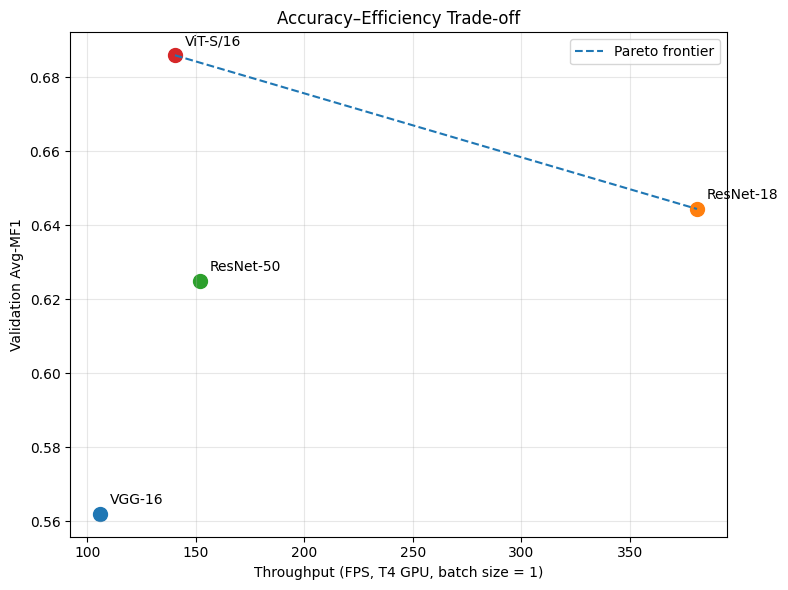

,Backbone,FPS,Avg-MF1,Pareto Optimal
0,VGG-16,105.85,0.5620,False
1,ResNet-18,381.01,0.6444,True
2,ResNet-50,152.03,0.6250,False
3,ViT-S/16,140.35,0.6860,True


Pareto-optimal models: ['ViT-S/16', 'ResNet-18']


In [13]:
# ============================================================
# FPS vs Avg-MF1 Pareto plot
# fps_df를 직접 사용
# ============================================================
import matplotlib.pyplot as plt


# FPS 측정 셀이 먼저 실행됐는지 확인
if "fps_df" not in globals():
    raise RuntimeError(
        "fps_df가 없습니다. 위의 FPS 측정 셀부터 실행하세요."
    )


# ------------------------------------------------------------
# 1. 각 모델이 다른 모델에 의해 지배되는지 확인
# ------------------------------------------------------------
def is_dominated(target_row, dataframe):
    for _, other_row in dataframe.iterrows():

        # 자기 자신은 비교하지 않음
        if other_row["Backbone"] == target_row["Backbone"]:
            continue

        # 다른 모델의 FPS와 MF1이 모두 현재 모델 이상인지
        no_worse = (
            other_row["FPS"] >= target_row["FPS"]
            and
            other_row["Avg-MF1"] >= target_row["Avg-MF1"]
        )

        # 두 값 중 하나 이상이 현재 모델보다 엄격히 높은지
        strictly_better = (
            other_row["FPS"] > target_row["FPS"]
            or
            other_row["Avg-MF1"] > target_row["Avg-MF1"]
        )

        if no_worse and strictly_better:
            return True

    return False


# ------------------------------------------------------------
# 2. Pareto-optimal 여부 계산
# ------------------------------------------------------------
fps_df = fps_df.copy()

fps_df["Pareto Optimal"] = [
    not is_dominated(row, fps_df)
    for _, row in fps_df.iterrows()
]


# Pareto 모델만 FPS 순서로 정렬
pareto_df = (
    fps_df[fps_df["Pareto Optimal"]]
    .sort_values("FPS")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. 그래프 작성
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in fps_df.iterrows():

    ax.scatter(
        row["FPS"],
        row["Avg-MF1"],
        s=100,
    )

    ax.annotate(
        row["Backbone"],
        (
            row["FPS"],
            row["Avg-MF1"],
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
    )


# Pareto frontier 연결
if len(pareto_df) >= 2:
    ax.plot(
        pareto_df["FPS"],
        pareto_df["Avg-MF1"],
        linestyle="--",
        linewidth=1.5,
        label="Pareto frontier",
    )

    ax.legend()


ax.set_xlabel(
    "Throughput (FPS, T4 GPU, batch size = 1)"
)
ax.set_ylabel("Validation Avg-MF1")
ax.set_title("Accuracy–Efficiency Trade-off")
ax.grid(True, alpha=0.3)

fig.tight_layout()


# logger가 존재할 때만 기록
if "logger" in globals():
    logger.log_image(
        "analysis/pareto",
        fig,
    )


plt.show()


# ------------------------------------------------------------
# 4. 결과 출력
# ------------------------------------------------------------
display(
    fps_df.style.format({
        "FPS": "{:.2f}",
        "Avg-MF1": "{:.4f}",
    })
)

print(
    "Pareto-optimal models:",
    pareto_df["Backbone"].tolist(),
)

In [14]:
logger.finish()